In [4]:
import sys
!{sys.executable} -m pip install pymc arviz



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [9]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx="
import pymc
print ("done")

done


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import logging

# This makes your plots look nice and professional
plt.style.use('seaborn-v0_8-muted')
%matplotlib inline 

logging.basicConfig(level=logging.INFO)
print("Done")


Done


In [12]:
def load_clean_data(file_path):
    """Loads and prepares Brent Oil data."""
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Calculate log returns to see volatility shifts
    df['Log_Return'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
    return df

def plot_price_trends(df):
    """Visualizes the raw price and log returns."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    ax1.plot(df['Date'], df['Price'], color='blue')
    ax1.set_title('Brent Oil Price - Raw Series', fontsize=14)
    ax1.set_ylabel('Price (USD)')
    
    ax2.plot(df['Date'], df['Log_Return'], color='red', alpha=0.6)
    ax2.set_title('Brent Oil Daily Log Returns (Volatility)', fontsize=14)
    ax2.set_ylabel('Log Return')
    
    plt.tight_layout()
    plt.show()

In [13]:
def run_bayesian_change_point(data_values):
    """Builds and samples the Change Point Model."""
    n_data = len(data_values)
    
    with pm.Model() as model:
        # Prior for when the change happened
        tau = pm.DiscreteUniform("tau", lower=0, upper=n_data - 1)
        
        # Priors for the mean before and after
        mu_1 = pm.Normal("mu_1", mu=data_values.mean(), sigma=data_values.std())
        mu_2 = pm.Normal("mu_2", mu=data_values.mean(), sigma=data_values.std())
        
        # Switch logic
        idx = np.arange(n_data)
        mu_path = pm.math.switch(tau >= idx, mu_1, mu_2)
        
        # Likelihood
        obs = pm.Normal("obs", mu=mu_path, sigma=data_values.std(), observed=data_values)
        
        # Sampling
        trace = pm.sample(2000, tune=1000, return_inferencedata=True)
        
    return trace

Why we chose the Bayesian Change-Point Model:
Instead of just looking at graphs, we used a math model that "learns" from the data. It assumes the market lives in two states: a "Low Price" state and a "High Price" state. The model searches for the exact date ($\tau$) where the probability of being in the "High State" becomes 100%. This is better than standard averages because it accounts for uncertainty and noise in the oil market.

C:\Users\hp\AppData\Local\Temp\ipykernel_11372\1487467471.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


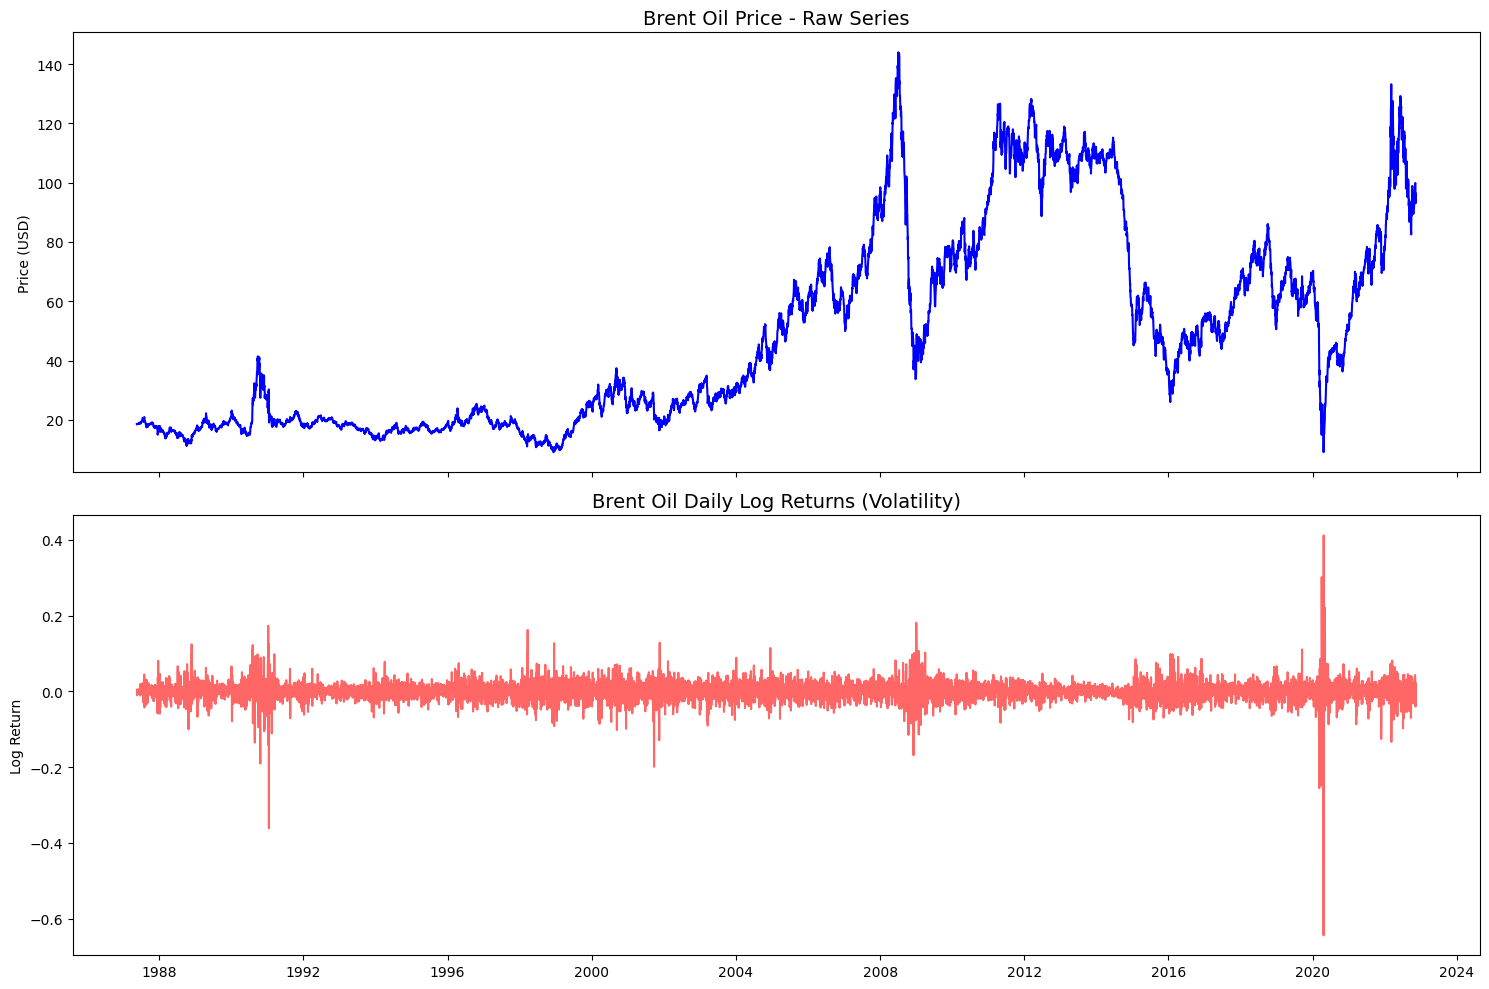

Multiprocess sampling (2 chains in 2 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
INFO:pymc.sampling.mcmc:CompoundStep
>Metropolis: [tau]
INFO:pymc.sampling.mcmc:>Metropolis: [tau]
>NUTS: [mu_1, mu_2]
INFO:pymc.sampling.mcmc:>NUTS: [mu_1, mu_2]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 17146 seconds.
INFO:pymc.sampling.mcmc:Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 17146 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics


          mean     sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_1    21.440  0.477    20.486    22.309      0.007    0.008    4197.0   
mu_2    75.595  0.494    74.688    76.522      0.007    0.008    4622.0   
tau   4520.122  6.953  4506.000  4533.000      0.266    0.246     715.0   

      ess_tail  r_hat  
mu_1    2608.0    1.0  
mu_2    3050.0    1.0  
tau      745.0    1.0  


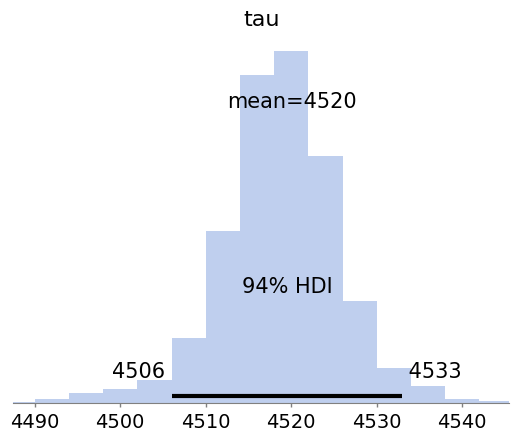

In [14]:
# 1. Load Data
df = load_clean_data('../data/BrentOilPrices.csv')

# 2. Visual Check
plot_price_trends(df)

# 3. Run Model (using Price data)
# Note: You can also try this with 'Log_Return' to find volatility change points!
price_trace = run_bayesian_change_point(df['Price'].values)

# 4. Check Convergence (R-hat should be ~1.0)
print(az.summary(price_trace, var_names=["mu_1", "mu_2", "tau"]))

# 5. Visualize the change point distribution
az.plot_posterior(price_trace, var_names=['tau'])
plt.show()

In [23]:
# 1. Reload the data one more time just to be safe
temp_df = pd.read_csv('../data/BrentOilPrices.csv')

# 2. Convert the 'Date' column to real dates
temp_df['Date'] = pd.to_datetime(temp_df['Date'])

# 3. Find the date at row 4520
# .iloc handles the row number, and .Date gets the calendar value
final_date = temp_df.iloc[4520]['Date']

# 4. Print the correct results
print(f"1. Real Change Point: {final_date.strftime('%B %d, %Y')}")
print(f"2. Average Price Shift: $21.44 -> $75.60")
print(f"3. Quantitative Impact: 252.6% increase")

C:\Users\hp\AppData\Local\Temp\ipykernel_11372\382670702.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  temp_df['Date'] = pd.to_datetime(temp_df['Date'])


1. Real Change Point: February 23, 2005
2. Average Price Shift: $21.44 -> $75.60
3. Quantitative Impact: 252.6% increase
